✅ Librairies chargées

📥 Téléchargement du dataset Pima Indians Diabetes (UCI)...
✅ Dataset chargé : 768 patients, 9 colonnes

📊 Distribution des classes :
Outcome
0    500
1    268
Name: count, dtype: int64
   - Non diabétiques (0) : 500 patients
   - Diabétiques (1) : 268 patients

📋 Aperçu des 5 premiers patients :
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288

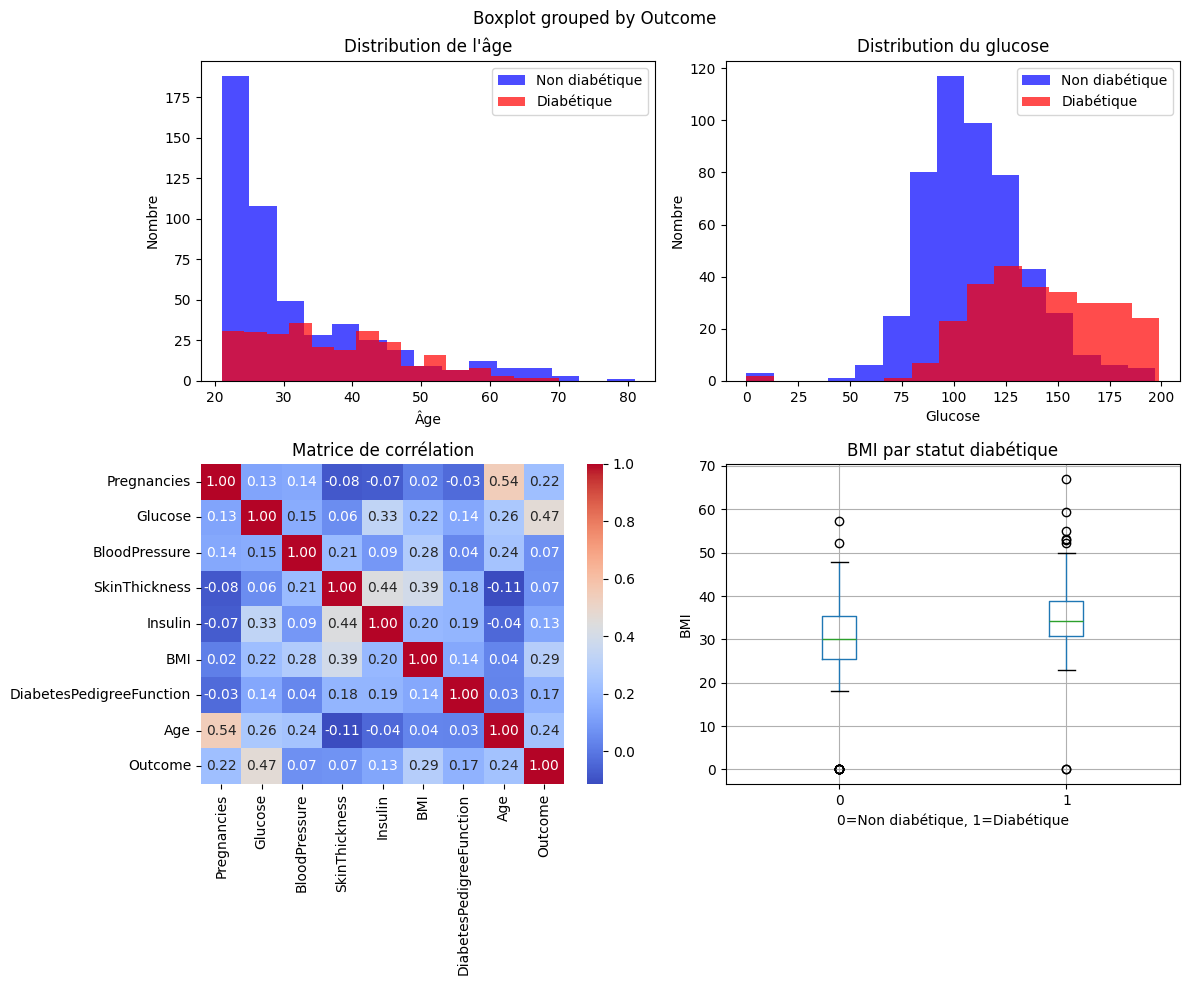


🔧 Prétraitement des données...
✅ Train set : 614 patients
✅ Test set : 154 patients
   - Non diabétiques test : 100
   - Diabétiques test : 54

ENTRAÎNEMENT DES 4 MODÈLES

📈 Entraînement de Régression Logistique...
   ✅ Accuracy : 0.7143
   ✅ Precision : 0.6087
   ✅ Recall : 0.5185
   ✅ F1-Score : 0.5600
   ✅ AUC : 0.8230

📈 Entraînement de Random Forest...
   ✅ Accuracy : 0.7597
   ✅ Precision : 0.6809
   ✅ Recall : 0.5926
   ✅ F1-Score : 0.6337
   ✅ AUC : 0.8145

📈 Entraînement de SVM...
   ✅ Accuracy : 0.7468
   ✅ Precision : 0.6471
   ✅ Recall : 0.6111
   ✅ F1-Score : 0.6286
   ✅ AUC : 0.7933

📈 Entraînement de XGBoost...
   ✅ Accuracy : 0.7792
   ✅ Precision : 0.7000
   ✅ Recall : 0.6481
   ✅ F1-Score : 0.6731
   ✅ AUC : 0.8244

TABLEAU COMPARATIF DES PERFORMANCES
                       accuracy precision    recall  f1_score       auc
Régression Logistique  0.714286  0.608696  0.518519      0.56  0.822963
Random Forest           0.75974  0.680851  0.592593  0.633663  0.814537
SVM

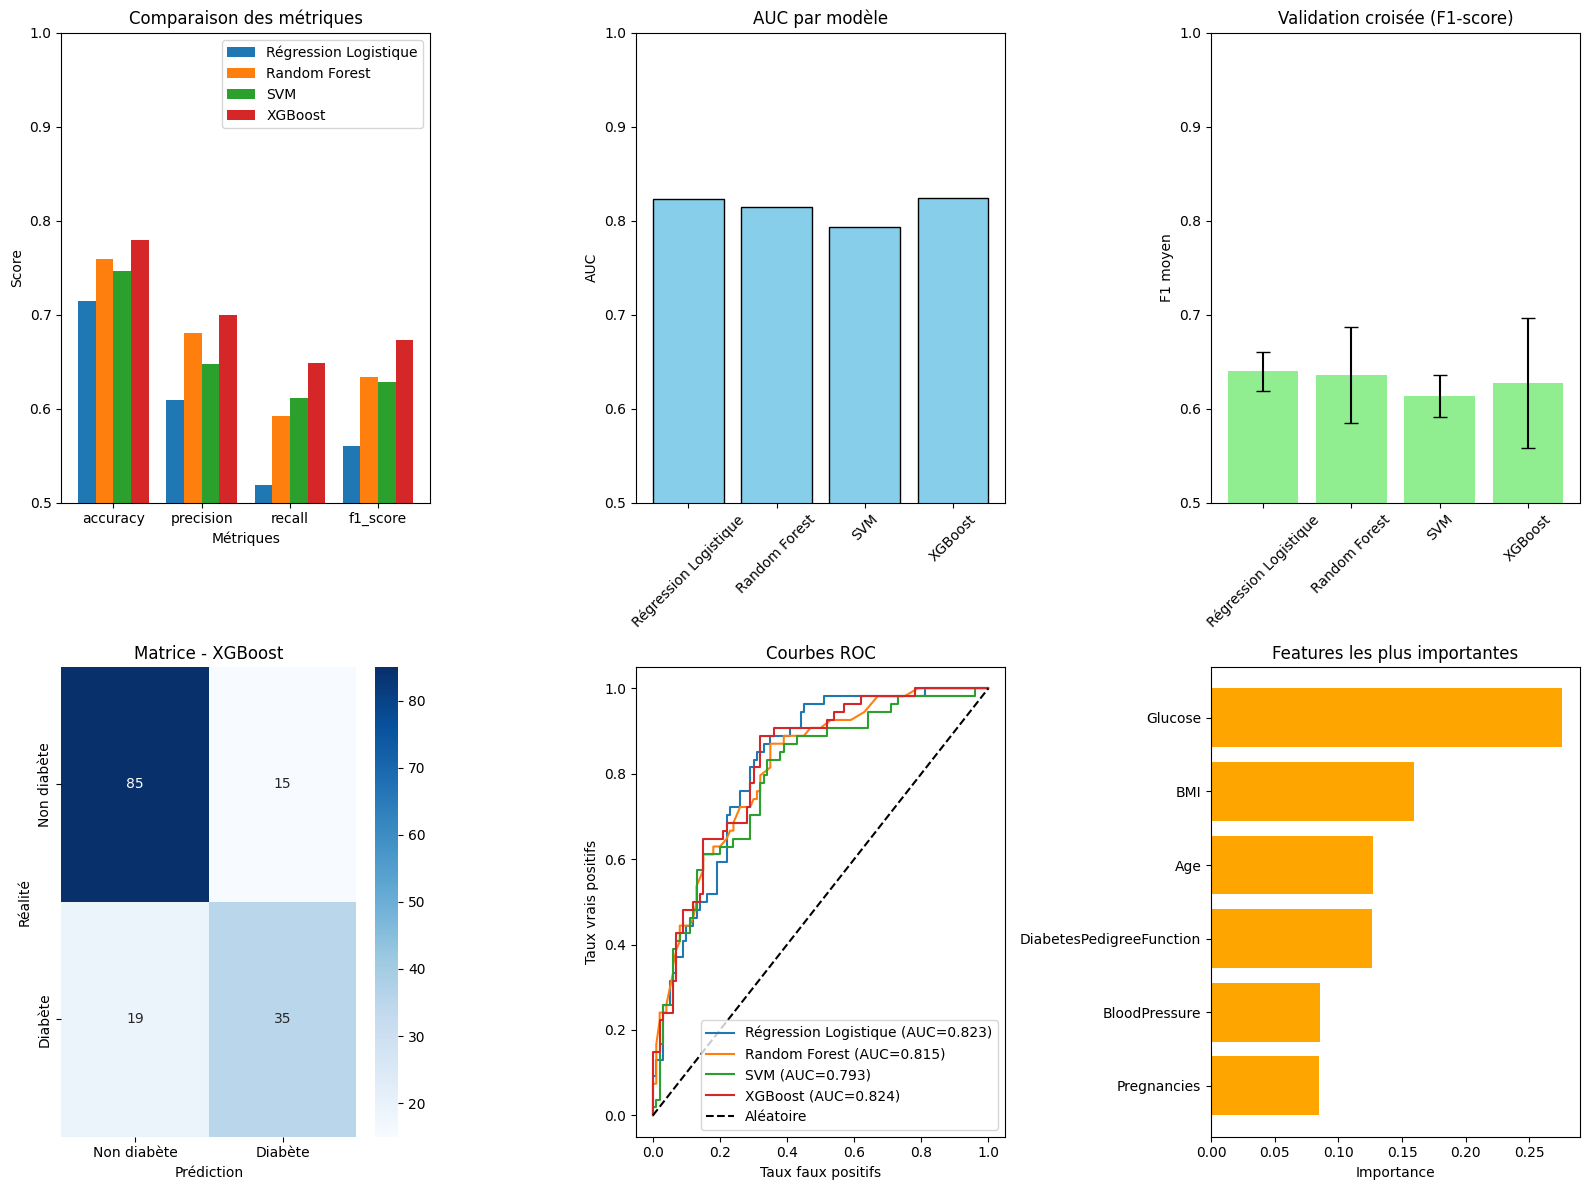


CONCLUSION

🏆 MEILLEUR MODÈLE : XGBoost
   - F1-Score : 0.6731
   - Accuracy : 0.7792
   - AUC : 0.8244

📊 CLASSEMENT DES MODÈLES (F1-Score) :
   1. XGBoost                   : F1 = 0.6731 | AUC = 0.8244
   2. Random Forest             : F1 = 0.6337 | AUC = 0.8145
   3. SVM                       : F1 = 0.6286 | AUC = 0.7933
   4. Régression Logistique     : F1 = 0.5600 | AUC = 0.8230

✅ Projet terminé avec succès !
📁 Dataset utilisé : Pima Indians Diabetes (UCI Machine Learning Repository)
📊 Taille : 768 patients, 8 variables médicales


In [3]:
# ============================================
# PROJET ML : Classification du diabète
# Dataset UCI : Pima Indians Diabetes
# 4 modèles : Logistic Regression, Random Forest, SVM, XGBoost
# ============================================

# ----- CELLULE 1 : Installation -----
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost

# ----- CELLULE 2 : Imports -----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies chargées")

# ----- CELLULE 3 : Téléchargement du dataset UCI -----
print("\n📥 Téléchargement du dataset Pima Indians Diabetes (UCI)...")

!wget -q https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df = pd.read_csv('pima-indians-diabetes.data.csv', names=columns)

print(f"✅ Dataset chargé : {df.shape[0]} patients, {df.shape[1]} colonnes")
print(f"\n📊 Distribution des classes :")
print(df['Outcome'].value_counts())
print(f"   - Non diabétiques (0) : {(df['Outcome']==0).sum()} patients")
print(f"   - Diabétiques (1) : {(df['Outcome']==1).sum()} patients")

print(f"\n📋 Aperçu des 5 premiers patients :")
print(df.head())

# ----- CELLULE 4 : Analyse exploratoire -----
print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE")
print("="*60)

print("\n📊 Statistiques descriptives :")
print(df.describe())

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distribution de l'âge
axes[0,0].hist(df[df['Outcome']==0]['Age'], bins=15, alpha=0.7, label='Non diabétique', color='blue')
axes[0,0].hist(df[df['Outcome']==1]['Age'], bins=15, alpha=0.7, label='Diabétique', color='red')
axes[0,0].set_xlabel('Âge')
axes[0,0].set_ylabel('Nombre')
axes[0,0].set_title('Distribution de l\'âge')
axes[0,0].legend()

# Distribution du glucose
axes[0,1].hist(df[df['Outcome']==0]['Glucose'], bins=15, alpha=0.7, label='Non diabétique', color='blue')
axes[0,1].hist(df[df['Outcome']==1]['Glucose'], bins=15, alpha=0.7, label='Diabétique', color='red')
axes[0,1].set_xlabel('Glucose')
axes[0,1].set_ylabel('Nombre')
axes[0,1].set_title('Distribution du glucose')
axes[0,1].legend()

# Matrice de corrélation
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[1,0], fmt='.2f')
axes[1,0].set_title('Matrice de corrélation')

# Boxplot BMI
df.boxplot(column='BMI', by='Outcome', ax=axes[1,1])
axes[1,1].set_title('BMI par statut diabétique')
axes[1,1].set_xlabel('0=Non diabétique, 1=Diabétique')
axes[1,1].set_ylabel('BMI')

plt.tight_layout()
plt.savefig('exploration_donnees.png', dpi=150)
plt.show()

# ----- CELLULE 5 : Prétraitement -----
print("\n🔧 Prétraitement des données...")

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Train set : {len(X_train)} patients")
print(f"✅ Test set : {len(X_test)} patients")
print(f"   - Non diabétiques test : {(y_test==0).sum()}")
print(f"   - Diabétiques test : {(y_test==1).sum()}")

# ----- CELLULE 6 : Définition des 4 modèles -----
models = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5,
                             random_state=42, use_label_encoder=False, eval_metric='logloss')
}

results = {}

print("\n" + "="*60)
print("ENTRAÎNEMENT DES 4 MODÈLES")
print("="*60)

for name, model in models.items():
    print(f"\n📈 Entraînement de {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    # Validation croisée 5-fold
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')

    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc': auc,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'predictions': y_pred,
        'probabilities': y_proba
    }

    print(f"   ✅ Accuracy : {accuracy:.4f}")
    print(f"   ✅ Precision : {precision:.4f}")
    print(f"   ✅ Recall : {recall:.4f}")
    print(f"   ✅ F1-Score : {f1:.4f}")
    print(f"   ✅ AUC : {auc:.4f}")

# ----- CELLULE 7 : Tableau comparatif -----
print("\n" + "="*60)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*60)

comparison_df = pd.DataFrame(results).T
print(comparison_df[['accuracy', 'precision', 'recall', 'f1_score', 'auc']].round(4))

# ----- CELLULE 8 : Visualisations -----
print("\n📊 Génération des graphiques...")

fig = plt.figure(figsize=(16, 12))

# 1. Barplot comparatif
ax1 = plt.subplot(2, 3, 1)
metrics = ['accuracy', 'precision', 'recall', 'f1_score']
x = np.arange(len(metrics))
width = 0.2
for i, (name, result) in enumerate(results.items()):
    values = [result[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=name)
ax1.set_xlabel('Métriques')
ax1.set_ylabel('Score')
ax1.set_title('Comparaison des métriques')
ax1.set_xticks(x + width*1.5)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim([0.5, 1.0])

# 2. AUC
ax2 = plt.subplot(2, 3, 2)
auc_values = [results[name]['auc'] for name in results.keys()]
ax2.bar(results.keys(), auc_values, color='skyblue', edgecolor='black')
ax2.set_title('AUC par modèle')
ax2.set_ylabel('AUC')
ax2.set_ylim([0.5, 1.0])
ax2.tick_params(axis='x', rotation=45)

# 3. Validation croisée
ax3 = plt.subplot(2, 3, 3)
cv_means = [results[name]['cv_mean'] for name in results.keys()]
cv_stds = [results[name]['cv_std'] for name in results.keys()]
ax3.bar(results.keys(), cv_means, yerr=cv_stds, capsize=5, color='lightgreen')
ax3.set_title('Validation croisée (F1-score)')
ax3.set_ylabel('F1 moyen')
ax3.set_ylim([0.5, 1.0])
ax3.tick_params(axis='x', rotation=45)

# 4. Matrice de confusion - Meilleur modèle
best_model = max(results, key=lambda x: results[x]['f1_score'])
ax4 = plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test, results[best_model]['predictions'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_title(f'Matrice - {best_model}')
ax4.set_xlabel('Prédiction')
ax4.set_ylabel('Réalité')
ax4.set_xticklabels(['Non diabète', 'Diabète'])
ax4.set_yticklabels(['Non diabète', 'Diabète'])

# 5. Courbes ROC
ax5 = plt.subplot(2, 3, 5)
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
    ax5.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.3f})")
ax5.plot([0,1], [0,1], 'k--', label='Aléatoire')
ax5.set_xlabel('Taux faux positifs')
ax5.set_ylabel('Taux vrais positifs')
ax5.set_title('Courbes ROC')
ax5.legend(loc='lower right')

# 6. Importance des features (Random Forest)
ax6 = plt.subplot(2, 3, 6)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-6:]
ax6.barh(np.array(X.columns)[indices], importances[indices], color='orange')
ax6.set_title('Features les plus importantes')
ax6.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('resultats_modeles.png', dpi=150)
plt.show()

# ----- CELLULE 9 : Conclusion -----
print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print(f"\n🏆 MEILLEUR MODÈLE : {best_model}")
print(f"   - F1-Score : {results[best_model]['f1_score']:.4f}")
print(f"   - Accuracy : {results[best_model]['accuracy']:.4f}")
print(f"   - AUC : {results[best_model]['auc']:.4f}")

print("\n📊 CLASSEMENT DES MODÈLES (F1-Score) :")
sorted_models = sorted(results.items(), key=lambda x: x[1]['f1_score'], reverse=True)
for i, (name, result) in enumerate(sorted_models, 1):
    print(f"   {i}. {name:25} : F1 = {result['f1_score']:.4f} | AUC = {result['auc']:.4f}")

print("\n✅ Projet terminé avec succès !")
print(f"📁 Dataset utilisé : Pima Indians Diabetes (UCI Machine Learning Repository)")
print(f"📊 Taille : {df.shape[0]} patients, {df.shape[1]-1} variables médicales")